## Imports

In [1]:
import os
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append(os.path.abspath(os.path.join(os.path.dirname("__file__"), '..')))

## Folders

In [2]:
images_dir = "../data/raw/Task03_Liver/imagesTr/"
labels_dir = "../data/raw/Task03_Liver/labelsTr/"

image_files = sorted([f for f in os.listdir(images_dir) if not f.startswith('._')])
label_files = sorted([f for f in os.listdir(labels_dir) if not f.startswith('._')])

print(f"Number of training images: {len(image_files)}")
print(f"Number of training labels: {len(label_files)}")


Number of training images: 131
Number of training labels: 131


## Load Example Image

In [8]:
# Pick one example
sample_idx = 52
image_path = os.path.join(images_dir, image_files[sample_idx])
label_path = os.path.join(labels_dir, label_files[sample_idx])

# Load NIfTI volumes
image_nib = nib.load(image_path)
label_nib = nib.load(label_path)

image = image_nib.get_fdata()
label = label_nib.get_fdata()

print("Image shape:", image.shape)
print("Label shape:", label.shape)
print("Image dtype:", image.dtype)
print("Label unique values:", np.unique(label))


Image shape: (512, 512, 129)
Label shape: (512, 512, 129)
Image dtype: float64
Label unique values: [0. 1. 2.]


## Plot Example Image Slices

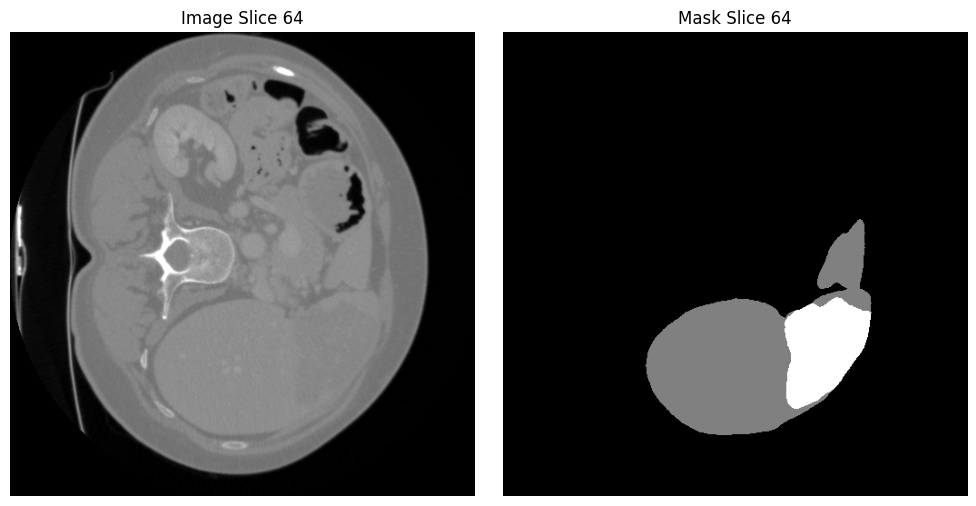

In [9]:
def plot_image_and_mask(image, mask, slice_idx):
    fig, axs = plt.subplots(1, 2, figsize=(10, 5))
    
    axs[0].imshow(image[:, :, slice_idx], cmap="gray")
    axs[0].set_title(f"Image Slice {slice_idx}")
    axs[0].axis('off')
    
    axs[1].imshow(mask[:, :, slice_idx], cmap="gray")
    axs[1].set_title(f"Mask Slice {slice_idx}")
    axs[1].axis('off')
    
    plt.tight_layout()
    plt.show()

# Plot a middle slice
middle_slice = image.shape[2] // 2
plot_image_and_mask(image, label, middle_slice)


## Examine Pixels in Sample Image

In [11]:
# Class pixel counts
unique, counts = np.unique(label, return_counts=True)
for cls, count in zip(unique, counts):
    percent = (count / label.size) * 100
    if cls == 0:
        cls_name = "Background"
    elif cls == 1:
        cls_name = "Liver"
    elif cls == 2:
        cls_name = "Tumor"
    else:
        cls_name = f"Class {cls}"
    print(f"{cls_name} pixels: {count} ({percent:.2f}%)")


Background pixels: 30951445 (91.53%)
Liver pixels: 2650863 (7.84%)
Tumor pixels: 214268 (0.63%)


## Which Slices of Sample Image Have Liver/Tumor

In [13]:
# For each slice, does it contain any liver?
slices_with_liver = np.sum(np.any(label == 1, axis=(0, 1)))
slices_with_tumor = np.sum(np.any(label == 2, axis=(0, 1)))
total_slices = label.shape[2]

print(f"Slices containing liver: {slices_with_liver}/{total_slices} ({(slices_with_liver/total_slices)*100:.2f}%)")
print(f"Slices containing tumor: {slices_with_tumor}/{total_slices} ({(slices_with_tumor/total_slices)*100:.2f}%)")

Slices containing liver: 98/129 (75.97%)
Slices containing tumor: 74/129 (57.36%)


## Sample Image Intensity

In [28]:
print(f"Image intensity mean: {np.mean(image):.2f}")
print(f"Image intensity std: {np.std(image):.2f}")


Image intensity mean: -439.77
Image intensity std: 519.96
